<a href="https://colab.research.google.com/github/naathycc/Estudos-para-projeto-trainee-de-dados/blob/main/05_quinta_semana/aprendizado_maquina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Aprendizado de Máquina**

A máquina aprende a reconhecer padrões, assim os modelos de aprendizagem conseguem tomar decisões ou façam previsões sem programação.

**Aprendizagem Supervisionada**

Para o treinamento usa-se conjuntos de dados, ensinando-os a identificar os padrões e as relações entre eles, com o objetivo de prever valores corretos para novas entradas.

**Algoritmos de Regressão**

1. **Regressão:** Algoritmo de ML que prevê valores numéricos.
* Previsão de custos, demanda, vendas, tempo.
*   A regressão tenta encontrar a melhor reta possível que relaciona as duas variáveis. Y = ax + b
*   **Regressão linear simples:** possui apenas uma variável.
Ex: área de uma região e seu valor.
Onde há diversas variáveis, como:
*   y → valor previsto (preço),
*   x → variável de entrada (área),
*   β₀ → intersecção(ponto em que a reta cruza o eixo y).
*   β₁ → coeficiente da variável(quanto o y aumenta quando a variável de entrada aumenta).
*   **Regressão linear múltipla:** várias variáveis de entrada interferem no valor previsto.


In [22]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [23]:
# Criação do DataFrame
funcionarios = pd.DataFrame({
    'anos_experiencia': [1, 2, 4, 5, 6, 7, 9],
    'salario': [2000, 3000, 3500, 4300, 4700, 5200, 6500]
})

print(funcionarios)

# Separando as variáveis
X = funcionarios[['anos_experiencia']]
y = funcionarios['salario']

# Separando os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Criando o modelo
regressao = LinearRegression()

# Treinando
regressao.fit(X_train, y_train)

# Fazendo previsões
y_pred = regressao.predict(X_test)

# Testando outra previsão
novo_funcionario = pd.DataFrame({
    "anos_experiencia": [10]
})
print(regressao.predict(novo_funcionario))

# Comparando os resultados
resultado = X_test.copy()

resultado["Salário Real"] = y_test.values
resultado["Salário Previsto"] = y_pred
print(resultado)

# Calculando as métricas
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

   anos_experiencia  salario
0                 1     2000
1                 2     3000
2                 4     3500
3                 5     4300
4                 6     4700
5                 7     5200
6                 9     6500
[7037.83783784]
   anos_experiencia  Salário Real  Salário Previsto
0                 1          2000       1832.432432
1                 2          3000       2410.810811
MAE: 378.38
MSE: 187611.40
RMSE: 433.14
R²: 0.25


2. **Decision Tree Regressor:** Algoritmo de ML supervisionado que divide os dados em grupos menores por meio de perguntas. Essa divisão é feita de forma recursiva para minimizar o erro de previsão.
Existem três partes:
*   Raiz (Root) → primeira pergunta.
*   Nó (Node) → perguntas intermediárias.
*   Folha (Leaf) → resposta final.
*   Pode decorar dados(overfitting).






   horas_estudo  nota_final
0             1         3.5
1             2         4.0
2             3         5.0
3             4         5.8
4             5         6.5
5             6         7.2
6             7         8.0
7             8         8.7
8             9         9.4
9            10        10.0
Nota prevista ´para um estudante que estudou 9,5 horas: 10.00
   horas_estudo  Nota Real  Nota Prevista
8             9        9.4           8.35
1             2        4.0           3.50
MAE: 0.78
MSE: 0.68
RMSE: 0.82
R²: 0.91


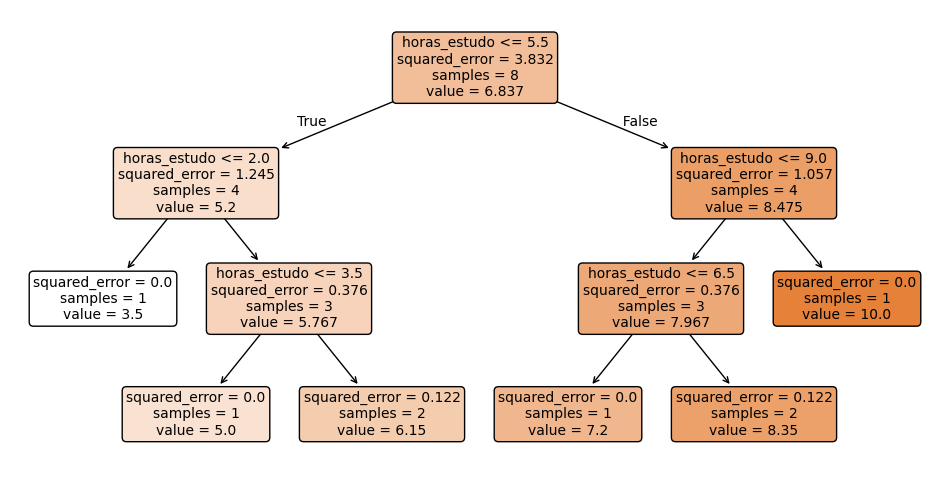

In [24]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree

estudantes = pd.DataFrame({
    'horas_estudo': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'nota_final': [3.5, 4.0, 5.0, 5.8, 6.5, 7.2, 8.0, 8.7, 9.4, 10.0]
})
print(estudantes)

X = estudantes[['horas_estudo']]
y = estudantes['nota_final']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Criando o modelo
arvore = DecisionTreeRegressor(
    random_state=42,
    max_depth=3
)

# Treinando
arvore.fit(X_train, y_train)

# Fazendo previsões
y_pred = arvore.predict(X_test)

# Comparando os resultados
resultado = X_test.copy()
resultado["Nota Real"] = y_test.values
resultado["Nota Prevista"] = y_pred

# Fazendo a previsão para um novo estudante
novo_estudante = pd.DataFrame({
    'horas_estudo': [9.5]
})

previsao = arvore.predict(novo_estudante)
print(f"Nota prevista ´para um estudante que estudou 9,5 horas: {previsao[0]:.2f}")
print(resultado)

# Calculando as métricas
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

# Visualização da árvore
plt.figure(figsize=(12,6))

plot_tree(
    arvore,
    feature_names=['horas_estudo'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()

3. **Random Forest:** Algoritmo de ML supervisionado que combina várias árvores de decisão, cada uma sendo treinada com amostras diferentes do conjunto de dados.


In [25]:
from sklearn.ensemble import RandomForestRegressor

carros = pd.DataFrame({
    'velocidade_media': [40, 50, 60, 70, 80, 90, 100, 110, 120, 130],
    'consumo_km_l': [18.5, 17.8, 17.0, 16.2, 15.3, 14.1, 13.0, 11.8, 10.5, 9.3]
})
print(carros)

X = carros[['velocidade_media']]
y = carros['consumo_km_l']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

floresta = RandomForestRegressor(
    n_estimators=50, # número de árvores de decisão
    random_state=42
)

# Treinando o modelo
floresta.fit(X_train, y_train)

# Fazendo previsões
y_pred = floresta.predict(X_test)

# Comparando os resultados
resultado = X_test.copy()

resultado["Consumo Real"] = y_test.values
resultado["Consumo Previsto"] = y_pred
print(resultado)

# Calculando as métricas
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

# Fazendo previsão para uma nova velocidade
novo_carro = pd.DataFrame({
    'velocidade_media': [85]
})
previsao = floresta.predict(novo_carro)
print(f"Consumo previsto: {previsao[0]:.2f} km/L")


   velocidade_media  consumo_km_l
0                40          18.5
1                50          17.8
2                60          17.0
3                70          16.2
4                80          15.3
5                90          14.1
6               100          13.0
7               110          11.8
8               120          10.5
9               130           9.3
   velocidade_media  Consumo Real  Consumo Previsto
8               120          10.5            11.344
1                50          17.8            17.910
MAE: 0.48
MSE: 0.36
RMSE: 0.60
R²: 0.97
Consumo previsto: 14.98 km/L


**Quando usar cada uma?**

• Regressão Linear:
Relação aproximadamente linear entre as variáveis, poucas variáveis e quando se deseja entender o impacto de cada variável independente sobre a variável alvo.
Ex.: previsão de vendas, relação entre área e preço de um imóvel.

• Decision Tree Regressor:
Quando os dados apresentam relações não lineares ou regras bem definidas. É um modelo fácil de interpretar, pois toma decisões por meio de perguntas, mas pode sofrer overfitting (decorar os dados de treino).

• Random Forest Regressor:
Quando se busca maior precisão e robustez. É indicado para problemas com muitas variáveis e relações complexas entre os dados. Utiliza várias árvores de decisão e combina suas previsões, reduzindo o overfitting.
Ex.: previsão de preços de imóveis, previsão de vendas, avaliação de risco de crédito.




**Algoritmo de Classificação**

Diferente da regressão que queremos prever um valor, na classificação queremos prever uma categoria, por exemplo: se um e-mail é spam ou não, se um aluno foi reprovado ou não, etc.

1. **Regressão Logística:** consegue prever a possibilidade de algum evento, assim indica se pertence a alguma característica ou não. Não funciona muito bem quando as relações são complexas.

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Criação do DataFrame
estudantes = pd.DataFrame({
    'horas_estudo': [1,2,3,4,5,6,7,8,9,10],
    'aprovado': [0,0,0,0,1,1,1,1,1,1]
})

print(estudantes)

# Separando as variáveis
X = estudantes[['horas_estudo']]
y = estudantes['aprovado']

# Separando os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Criando o modelo
modelo = LogisticRegression()

# Treinando o modelo
modelo.fit(X_train, y_train)

# Fazendo previsões
y_pred = modelo.predict(X_test)

# Fazendo a previsão para um novo estudante
novo_estudante = pd.DataFrame({ 'horas_estudo': [7] })
previsao = modelo.predict(novo_estudante)
print(f"\nPrevisão:")
if previsao[0] == 1:
    print("Esse estudante vai passar.")
else:
    print("Esse estudante vai reprovar.")

# Comparando os resultados
resultado = X_test.copy()
resultado["Resultado Real"] = y_test.values
resultado["Resultado Previsto"] = y_pred

print(resultado)

# Calculando a acurácia
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia: {accuracy:.2f}") # O modelo acertou quantas previsões? Quanto maior, melhor.

# Exibindo a matriz de confusão
print("\nMatriz de Confusão")
print(confusion_matrix(y_test, y_pred)) # Mostra onde o modelo errou ou acertou.

# Exibindo o relatório de classificação
print("\nRelatório de Classificação")
print(classification_report(y_test, y_pred)) # métricas de classificação, como Precision, Recall, F1-score e Support.

   horas_estudo  aprovado
0             1         0
1             2         0
2             3         0
3             4         0
4             5         1
5             6         1
6             7         1
7             8         1
8             9         1
9            10         1

Previsão:
Esse estudante vai passar.
   horas_estudo  Resultado Real  Resultado Previsto
8             9               1                   1
1             2               0                   0
Acurácia: 1.00

Matriz de Confusão
[[1 0]
 [0 1]]

Relatório de Classificação
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

